In [8]:
# 1. Install the translator for MicroPython
!pip install m2cgen

import pandas as pd
import numpy as np
import joblib
import os
import m2cgen as m2c
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# ===============================
# 2. LOAD DATA (FIXED FOR ENCODING ERROR)
# ===============================
data_folder = 'data' # Ensure your 13 CSVs are in this folder
all_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]
print(f"Found {len(all_files)} files.")

data_list = []
for file in all_files:
    activity_name = file.split('_')[0] # Takes the first part of the filename
    try:
        # 'latin1' encoding fixes the UnicodeDecodeError 0x96
        df = pd.read_csv(os.path.join(data_folder, file), encoding='latin1')
        df['activity'] = activity_name
        data_list.append(df)
        print(f"Loaded: {activity_name} ({len(df)} rows)")
    except Exception as e:
        print(f"Could not load {file}: {e}")

full_df = pd.concat(data_list, ignore_index=True)

# ===============================
# 3. FEATURE EXTRACTION
# ===============================
WINDOW_SIZE = 20
STEP_SIZE = 10
imu_cols = ["ax", "ay", "az", "gx", "gy", "gz"]

def extract_features(window):
    features = []
    for col in imu_cols:
        v = window[col].values
        mean_v = np.mean(v)
        iqr = np.percentile(v, 75) - np.percentile(v, 25)
        # Zero Crossing Rate
        zcr = np.sum(np.diff(np.sign(v - mean_v)) != 0)

        features.extend([
            mean_v, np.min(v), np.max(v), np.std(v), np.var(v),
            np.sqrt(np.mean(v**2)), np.sum(v**2), np.median(v), iqr, zcr
        ])
    # Add last raw values (to reach 66 features total)
    features.extend(window[imu_cols].iloc[-1].values.tolist())
    return features

X, y = [], []
for activity in full_df['activity'].unique():
    act_df = full_df[full_df['activity'] == activity].ffill().bfill()
    for i in range(0, len(act_df) - WINDOW_SIZE, STEP_SIZE):
        window = act_df.iloc[i:i+WINDOW_SIZE]
        X.append(extract_features(window))
        y.append(activity)

X = np.nan_to_num(np.array(X))
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ===============================
# 4. TRAIN AND EXPORT
# ===============================
model = DecisionTreeClassifier(max_depth=12, min_samples_leaf=5)
model.fit(X, y_encoded)

# Output the Activity Map for your Deployment script
mapping = {i: label for i, label in enumerate(le.classes_)}
print("\n" + "="*40)
print("COPY THIS TO YOUR DEPLOYMENT SCRIPT:")
print(f"activity_map = {mapping}")
print("="*40 + "\n")

# Convert Model to Pure Python (MicroPython compatible)
model_code = m2c.export_to_python(model)
with open("model_logic.py", "w") as f:
    f.write(model_code)

print("Finished! Download 'model_logic.py' from the files tab on the left.")

Found 13 files.
Loaded: Sitting (8997 rows)
Loaded: Pick and Place (8960 rows)
Loaded: Standing (8994 rows)
Loaded: Brisk walking (8919 rows)
Loaded: Sit (8912 rows)
Loaded: Cycling (8384 rows)
Loaded: Jogging (8909 rows)
Loaded: Eating with Spoon (8986 rows)
Loaded: Jumping (8991 rows)
Loaded: Stair (8938 rows)
Loaded: Stair (8948 rows)
Loaded: Phone Interaction (8929 rows)
Loaded: Walking (8931 rows)

COPY THIS TO YOUR DEPLOYMENT SCRIPT:
activity_map = {0: np.str_('Brisk walking'), 1: np.str_('Cycling'), 2: np.str_('Eating with Spoon'), 3: np.str_('Jogging'), 4: np.str_('Jumping'), 5: np.str_('Phone Interaction'), 6: np.str_('Pick and Place'), 7: np.str_('Sit'), 8: np.str_('Sitting'), 9: np.str_('Stair'), 10: np.str_('Standing'), 11: np.str_('Walking')}

Finished! Download 'model_logic.py' from the files tab on the left.


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
from sklearn.model_selection import train_test_split

# ============================================================
# DATASET PARTITIONING & MODEL INITIALIZATION
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


In [11]:
# ---------------------------------------------------------
# BUILD & TRAIN: Decision Tree Classifier
# ---------------------------------------------------------

# Initializing the classifier with constraints to prevent overfitting
# depth=12 and min_leaf=5 are chosen for TinyML memory efficiency
clf_dt = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=5,
    random_state=42
)

print(f"\n{'='*30}\nFitting Decision Tree Model...\n{'='*30}")
clf_dt.fit(X_train, y_train)

# Run inference on the test set
predictions = clf_dt.predict(X_test)

# Evaluate performance
dt_acc = accuracy_score(y_test, predictions)

print(f"Process Complete.")
print(f"Model Performance (Raw): {dt_acc:.4f}")
print(f"Overall Accuracy: {dt_acc * 100:.2f}%")


Fitting Decision Tree Model...
Process Complete.
Model Performance (Raw): 0.9563
Overall Accuracy: 95.63%


In [13]:
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_test, predictions))


CLASSIFICATION REPORT
                   precision    recall  f1-score   support

    Brisk walking       0.98      0.94      0.96       178
          Cycling       0.96      0.97      0.96       167
Eating with Spoon       0.94      0.90      0.92       179
          Jogging       0.97      1.00      0.99       178
          Jumping       1.00      0.99      0.99       180
Phone Interaction       0.98      0.99      0.99       178
   Pick and Place       0.91      0.93      0.92       179
              Sit       0.87      0.85      0.86       178
          Sitting       0.99      1.00      1.00       180
            Stair       0.93      0.95      0.94       358
         Standing       1.00      0.97      0.99       180
          Walking       0.98      0.98      0.98       178

         accuracy                           0.96      2313
        macro avg       0.96      0.96      0.96      2313
     weighted avg       0.96      0.96      0.96      2313



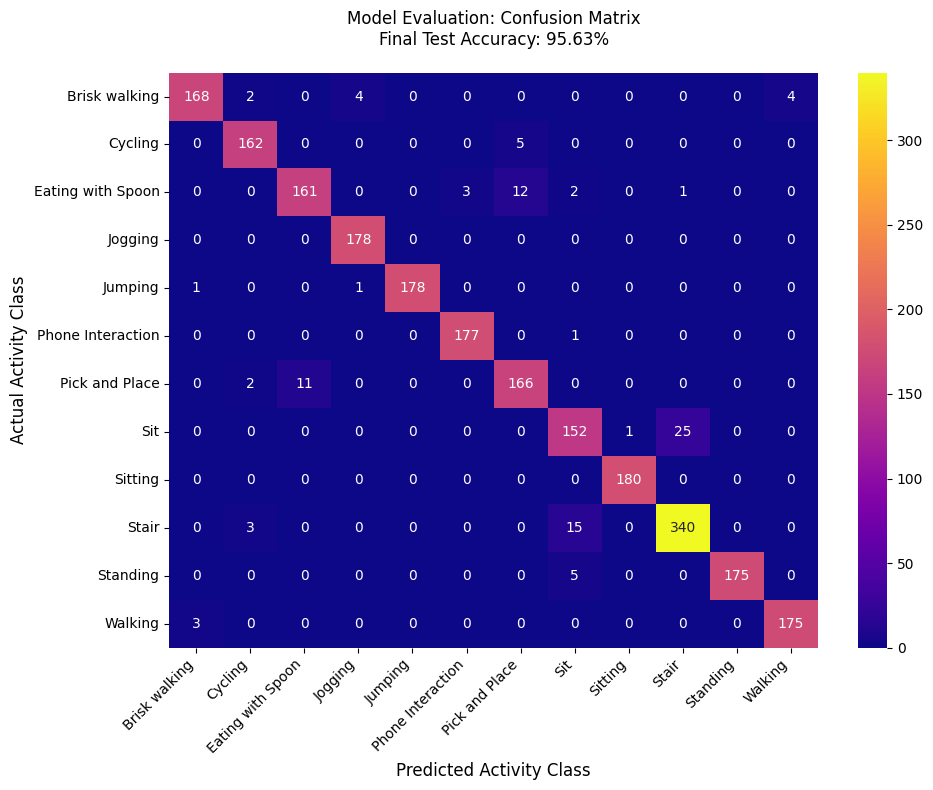


[INFO] Confusion matrix successfully exported to: dt_confusion_matrix_results.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# VISUALIZATION: Confusion Matrix Evaluation
# ---------------------------------------------------------

# Compute matrix using labels from the test set for alignment
conf_mat = confusion_matrix(y_test, predictions)
labels = sorted(list(set(y_test)))

# Setup plot style and size
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="plasma",  # A clean, professional green-blue gradient
    xticklabels=labels,
    yticklabels=labels,
    antialiased=True
)

# Adding context and metadata to the plot
plt.title(f"Model Evaluation: Confusion Matrix\nFinal Test Accuracy: {dt_acc:.2%}", pad=20)
plt.xlabel("Predicted Activity Class", fontsize=12)
plt.ylabel("Actual Activity Class", fontsize=12)

# Cleanup alignment for long labels (like 'Brisk_Walking')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Export the figure before rendering
output_filename = "dt_confusion_matrix_results.png"
plt.tight_layout()
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[INFO] Confusion matrix successfully exported to: {output_filename}")

In [22]:
# =================================================================
# FEATURE ENGINEERING PIPELINE
# =================================================================

# Hyperparameters for the sliding window approach
WIN_LEN = 20  # Samples per window
OVERLAP = 10  # Step size for window advancement

# Sensor axes from the IMU
channels = ["ax", "ay", "az", "gx", "gy", "gz"]

def compute_window_stats(data_window):
    """
    Computes time-domain statistical descriptors for a single window.
    Designed for efficient feature extraction in TinyML contexts.
    """
    extracted_vector = []

    for axis in channels:
        raw_vals = data_window[axis].values

        # Calculate Zero-Crossing Rate (ZCR)
        # We check for constant signal to avoid noise in flatlines
        if np.all(raw_vals == raw_vals[0]):
            z_rate = 0
        else:
            z_rate = np.sum(np.diff(np.sign(raw_vals)) != 0)

        # Calculate spread via Interquartile Range
        q75, q25 = np.percentile(raw_vals, [75, 25])
        iq_range = q75 - q25

        # Compile statistical profile for the current axis
        extracted_vector.extend([
            np.mean(raw_vals),                 # Average
            np.min(raw_vals),                  # Minimum
            np.max(raw_vals),                  # Maximum
            np.std(raw_vals),                  # Standard Deviation
            np.var(raw_vals),                  # Variance
            np.sqrt(np.mean(raw_vals**2)),     # RMS
            np.sum(raw_vals**2),               # Signal Energy
            np.median(raw_vals),               # Median
            iq_range,                          # IQR
            z_rate                             # ZCR
        ])

    return extracted_vector

# --- Metadata Generation ---
stat_types = ["mean", "min", "max", "std", "var", "rms", "energy", "median", "iqr", "zcr"]

# Generate descriptive names for all features
final_feature_list = [f"{ch}_{stat}" for ch in channels for stat in stat_types]

# Append the final sample of the window as a 'last_value' feature
final_feature_list += [f"{ch}_last" for ch in channels]

print(f"Feature Engineering Complete.")
print(f"Total dimensionality of input vector: {len(final_feature_list)}")

Feature Engineering Complete.
Total dimensionality of input vector: 66



RANK  FEATURE                   IMPORTANCE
   ay_min 0.254568
   az_min 0.087752
ay_median 0.085479
  ax_mean 0.085391
   ax_var 0.083048
   gz_rms 0.081052
az_median 0.074873
   ay_max 0.073440
   az_rms 0.066345
   ax_rms 0.018962
   ax_max 0.012995
ax_energy 0.009943
gy_energy 0.006620
   gy_std 0.006134
   ay_var 0.005589
  gx_last 0.005362
   gx_std 0.004338
   gy_rms 0.004201
  ax_last 0.004164
  az_mean 0.004052


/tmp/ipython-input-218423601.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


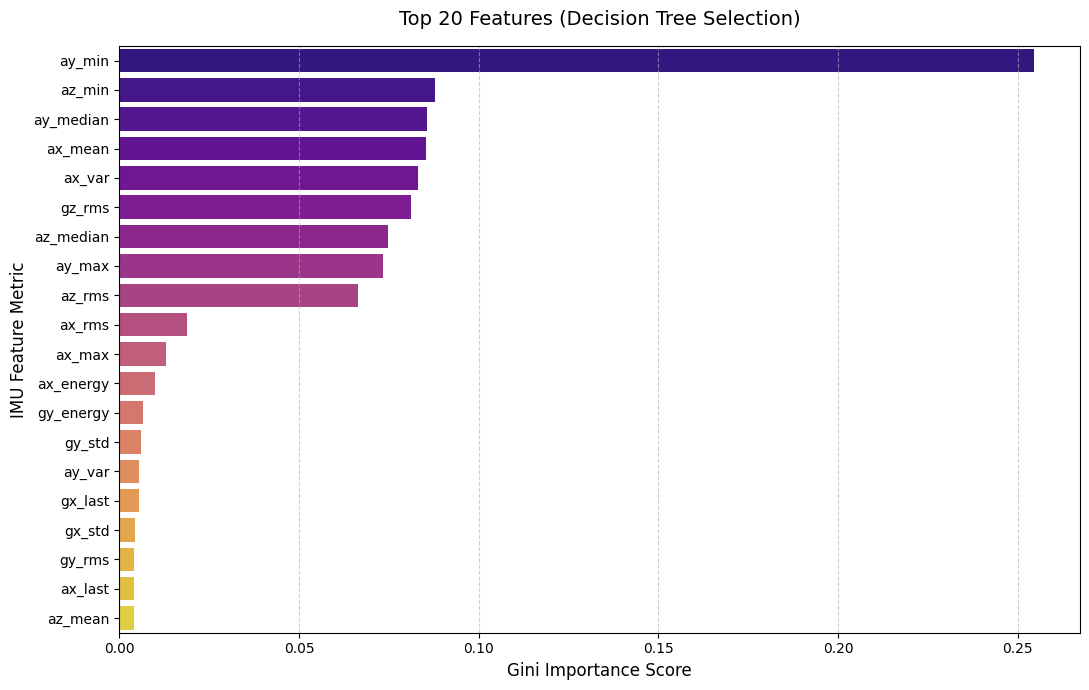


[OUTPUT] Ranking plot saved as: dt_feature_ranking.png


In [28]:
# ---------------------------------------------------------
# ANALYSIS: Identifying Key Signal Predictors
# ---------------------------------------------------------

# Mapping feature labels to their calculated importance scores
importance_df = pd.DataFrame({
    'feature_name': final_feature_list,
    'score': clf_dt.feature_importances_
}).sort_values(by='score', ascending=False)

print(f"\n{'='*40}")
print(f"{'RANK':<5} {'FEATURE':<25} {'IMPORTANCE'}")
print(f"{'='*40}")
print(importance_df.head(20).to_string(index=False, header=False))

# Visualization: Top 20 Predictors
plt.figure(figsize=(11, 7))
sns.barplot(
    data=importance_df.head(20),
    x='score',
    y='feature_name',
    palette='plasma' # Professional color gradient
)

plt.title("Top 20 Features (Decision Tree Selection)", fontsize=14, pad=15)
plt.xlabel("Gini Importance Score", fontsize=12)
plt.ylabel("IMU Feature Metric", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Save and render
img_output = "dt_feature_ranking.png"
plt.tight_layout()
plt.savefig(img_output, dpi=300)
plt.show()

print(f"\n[OUTPUT] Ranking plot saved as: {img_output}")

In [29]:
# ---------------------------------------------------------
# MODEL PERSISTENCE: Exporting for Deployment
# ---------------------------------------------------------

# Define the export path
model_filename = "trained_dt_classifier.pkl"

# Serialize the model object to disk
try:
    joblib.dump(clf_dt, model_filename)

    print(f"\n{'#'*50}")
    print(f"  SUCCESS: Model successfully serialized.")
    print(f"  Filename: {model_filename}")
    print(f"{'#'*50}")

except Exception as e:
    print(f"An error occurred while saving the model: {e}")


##################################################
  SUCCESS: Model successfully serialized.
  Filename: trained_dt_classifier.pkl
##################################################
